In [1]:
!pip install -q seaborn

In [2]:
# Basic imports and setup
import os
import yaml
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import SNAC-pack utilities
from utils.tf_global_search5 import run_mlp_search
from utils.tf_visualization import plot_pareto_fronts, plot_3d_pareto_front_heatmap
from utils.tf_local_search_separated import local_search_entrypoint
# from utils.tf_local_search2 import local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_mnist
import seaborn as sns


# np.random.seed(42)
# tf.random.set_seed(42)

# Plotting settings and TF logging
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
tf.get_logger().setLevel('ERROR')
print("TensorFlow Version:", tf.__version__)

# --- Configuration ---
N_TRIALS_MLP = 5 # Note: Increase for a real search, 15 is for a quick demo
EPOCHS_MLP = 10
SUBSET_SIZE_MLP = 10000
RESULTS_DIR_MLP = "./results/tutorial1_MLP_Hardware_Aware"

os.makedirs(RESULTS_DIR_MLP, exist_ok=True)

2025-08-31 17:38:28.853700: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow Version: 2.15.0


## The Dataset: MNIST

We'll use the classic MNIST dataset of handwritten digits. First, let's load it and visualize a few examples to see what we're working with.


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 8, 8, 1), x_val shape: (10000, 8, 8, 1)
  y_train shape: (10000,), y_val shape: (10000,)


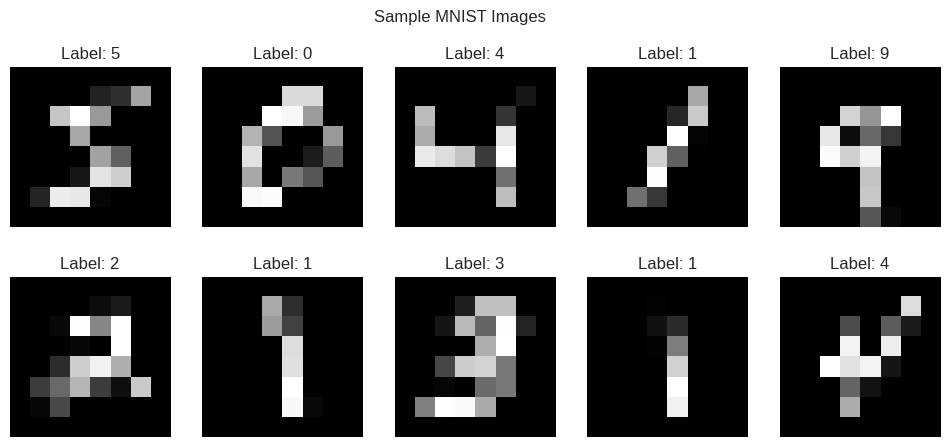

In [3]:

# Load the data for visualization (un-flattened)
x_train_viz, y_train_viz, _, _ = load_and_preprocess_mnist(
    subset_size=SUBSET_SIZE_MLP, 
    flatten=False, 
    one_hot=False
)

# Visualize the first 10 images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_viz[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train_viz[i]}")
    plt.axis('off')
plt.suptitle("Sample MNIST Images")
plt.show()

## Global Search: Finding the Best Architectural Trade-offs

Now, we run the global search. We are not looking for a single "best" model, but the **Pareto optimal front** of models that offer the best balance across four competing objectives:

1.  **Accuracy** (Maximize)
2.  **BOPs** (Minimize)
3.  **FPGA Resources** (Avg. Resource %) (Minimize)
4.  **Latency** (Clock Cycles) (Minimize)

We enable this by setting `use_hardware_metrics=True`, which activates the `rule4ml` integration.


In [ ]:

# --- Objectives for Hardware-Aware Search ---
OBJECTIVE_NAMES_HW = ['performance_metric', 'bops', 'avg_resource', 'clock_cycles']
MAXIMIZE_FLAGS_HW = [True, False, False, False] # True = maximize, False = minimize
OBJECTIVE_INFO_HW = list(zip(OBJECTIVE_NAMES_HW, MAXIMIZE_FLAGS_HW))


# --- Run the MLP Hardware-Aware Search ---
print("\n" + "="*50)
print("Running Part 1: MLP Hardware-Aware Global Search...")
print("This may take a few minutes...")
print("="*50)

study_mlp, searcher_mlp = run_mlp_search(
    results_dir=RESULTS_DIR_MLP,
    n_trials=N_TRIALS_MLP,
    epochs=EPOCHS_MLP,
    subset_size=SUBSET_SIZE_MLP,
    use_hardware_metrics=True # This is the key for hardware co-design!
)

print("\nGlobal Search Complete!")


Running Part 1: MLP Hardware-Aware Global Search...
This may take a few minutes...

Starting MLP Global Search on MNIST



[I 2025-08-31 17:38:34,585] A new study created in memory with name: no-name-f882418e-8dac-4244-928e-516b59b450c5


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 64), x_val shape: (10000, 64)
  y_train shape: (10000, 10), y_val shape: (10000, 10)


## Analyzing the Global Search Results
The search is complete! The results contain the performance of every architecture tried. Let's visualize the Pareto fronts to understand the trade-offs.



--- Visualizing Hardware-Aware Pareto Fronts ---
2D Pareto fronts plot saved to ./results/tutorial1_MLP_Hardware_Aware/pareto_fronts_2d.png


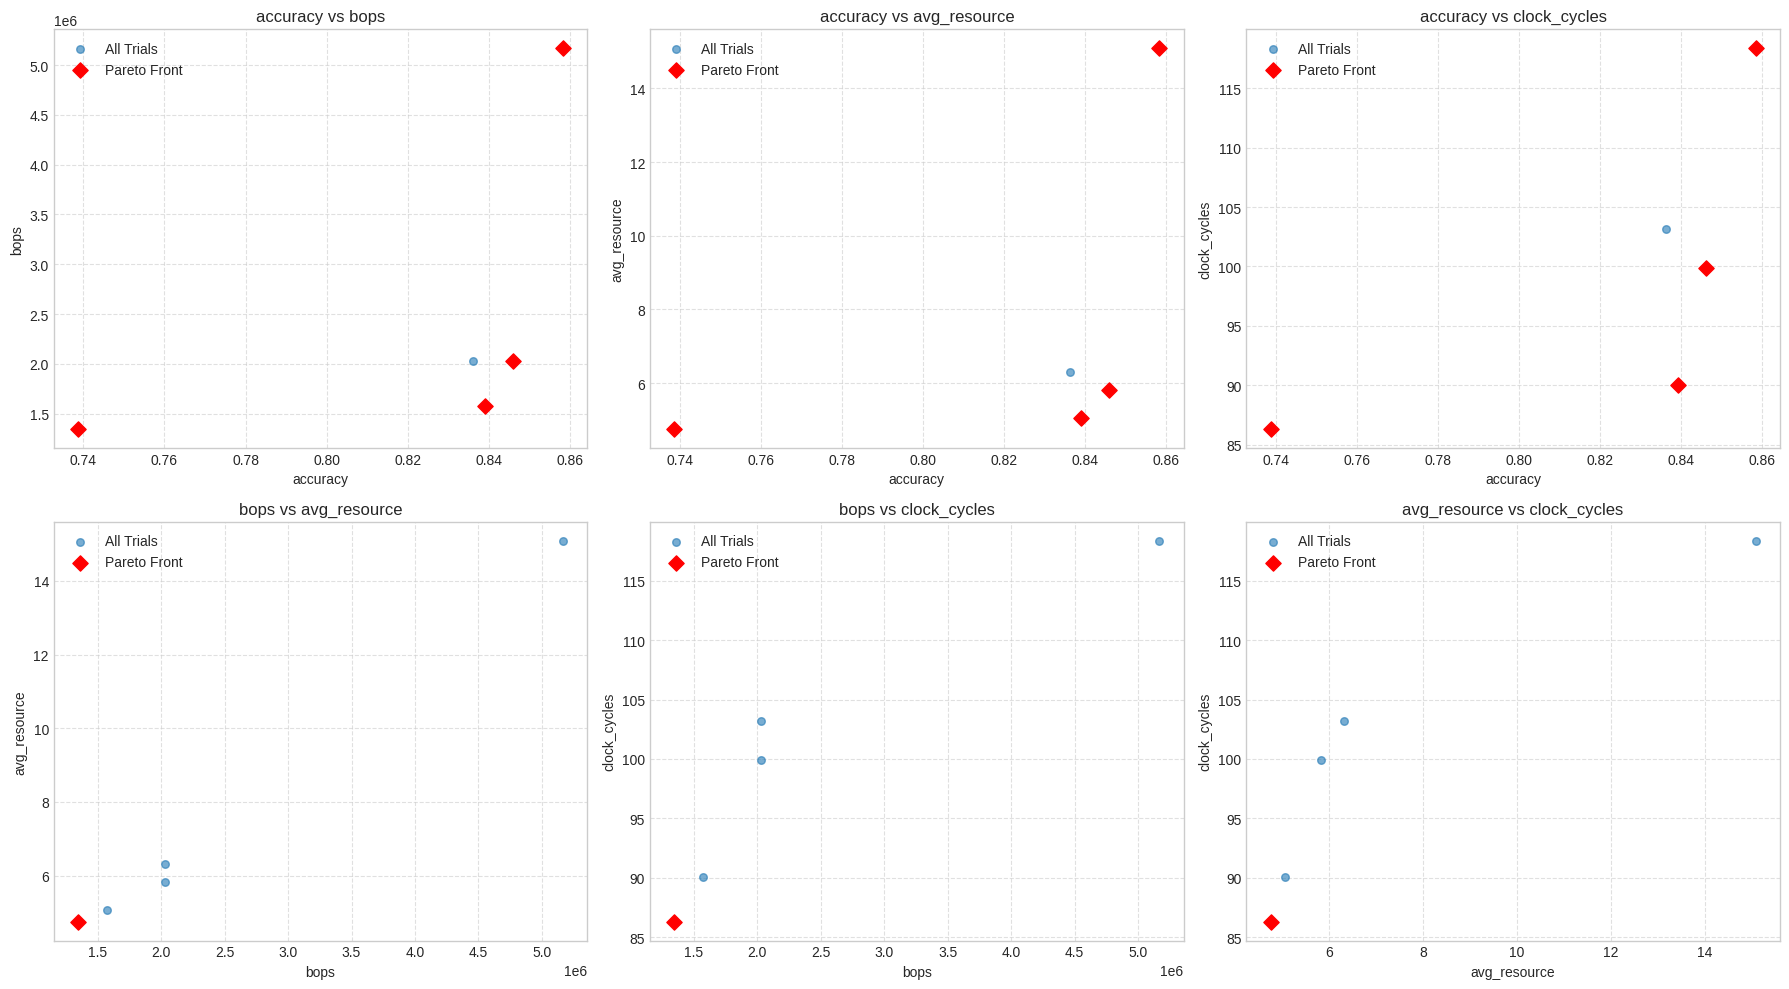


--- Generating 3D Pareto Front Heatmap ---
3D Pareto front plot saved to ./results/tutorial1_MLP_Hardware_Aware/pareto_front_3d.html



MLP search plots saved to: ./results/tutorial1_MLP_Hardware_Aware


In [ ]:

results_df_mlp = pd.DataFrame(searcher_mlp.results)

if not results_df_mlp.empty:
    print("\n--- Visualizing Hardware-Aware Pareto Fronts ---")
    # Rename 'performance_metric' to 'accuracy' for clearer plot labels
    results_df_mlp.rename(columns={'performance_metric': 'accuracy'}, inplace=True)
    OBJECTIVE_INFO_HW[0] = ('accuracy', True)
    
    plot_pareto_fronts(results_df_mlp, OBJECTIVE_INFO_HW, save_dir=searcher_mlp.results_dir)
    
    print("\n--- Generating 3D Pareto Front Heatmap ---")
    plot_3d_pareto_front_heatmap(results_df_mlp, OBJECTIVE_INFO_HW, save_dir=searcher_mlp.results_dir)
    
    print(f"\nMLP search plots saved to: {searcher_mlp.results_dir}")
else:
    print("MLP search did not yield any results.")

## Local Search: Compressing the Best Model

The global search automatically saved the configuration of the best-performing model (`best_model_for_local_search.yaml`). Now, we'll take this champion architecture and make it even more efficient through **Quantization-Aware Training (QAT)** and **iterative pruning**.


In [ ]:
# # Basic imports and setup
# import os
# import yaml
# import tensorflow as tf
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Import SNAC-pack utilities
# from utils.tf_global_search5 import run_mlp_search
# from utils.tf_visualization import plot_pareto_fronts, plot_3d_pareto_front_heatmap
# from utils.tf_local_search_separated import local_search_entrypoint
# from utils.tf_data_preprocessing import load_and_preprocess_mnist


# RESULTS_DIR_MLP = "./results/tutorial1_MLP_Hardware_Aware"
# SUBSET_SIZE_MLP = 20000


2025-08-31 17:36:41.714195: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# --- NEW: Configuration for Separated Local Search ---
LOCAL_SEARCH_RESULTS_DIR = os.path.join(RESULTS_DIR_MLP, "local_search_separated")
LOCAL_SEARCH_CONFIG_PATH = os.path.join(RESULTS_DIR_MLP, 'local_search_settings_separated.yaml')

# Define settings with distinct sections for pruning and QAT
local_search_settings = {
    'pruning_settings': {
        'iterations': 8,
        'epochs_per_iteration': 5,
        'pruning_rate': 0.8, # Prune 20% of remaining weights each iteration
    },
    'qat_settings': {
        'epochs': 15, # Epochs to fine-tune each quantized model
        'precision_pairs': [
            {'total_bits': 16, 'int_bits': 6},
            {'total_bits': 8, 'int_bits': 3},
            {'total_bits': 6, 'int_bits': 2},
            {'total_bits': 4, 'int_bits': 1},
        ]
    }
}

# Write the new settings to a YAML file
with open(LOCAL_SEARCH_CONFIG_PATH, 'w') as f:
    yaml.dump(local_search_settings, f)
print(f"Created separated local search configuration file: {LOCAL_SEARCH_CONFIG_PATH}")

# Path to the best model found by the global search
ARCHITECTURE_YAML_PATH = os.path.join(RESULTS_DIR_MLP, "best_model_for_local_search.yaml")

# --- Load Dataset for Local Search ---
x_train, y_train, x_val, y_val = load_and_preprocess_mnist(
    resize_val=8, subset_size=SUBSET_SIZE_MLP, flatten=False, one_hot=True
)

# --- Run the Separated Local Search ---
if os.path.exists(ARCHITECTURE_YAML_PATH):
    pruning_results_df, qat_results_df = local_search_entrypoint(
        architecture_yaml_path=ARCHITECTURE_YAML_PATH,
        local_search_config_path=LOCAL_SEARCH_CONFIG_PATH,
        dataset=(x_train, y_train, x_val, y_val),
        results_dir=LOCAL_SEARCH_RESULTS_DIR
    )
else:
    print(f"ERROR: Could not find the architecture file: {ARCHITECTURE_YAML_PATH}")
    pruning_results_df, qat_results_df = pd.DataFrame(), pd.DataFrame()

Created separated local search configuration file: ./results/tutorial1_MLP_Hardware_Aware/local_search_settings_separated.yaml
Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (20000, 8, 8, 1), x_val shape: (10000, 8, 8, 1)
  y_train shape: (20000, 10), y_val shape: (10000, 10)

 STARTING SEPARATED LOCAL SEARCH STAGE 

-------------------- Starting Pruning-Only Experiment --------------------

Pruning Iteration 1/8 - Target Sparsity: 0.2000
Epoch 1/5
157/157 [==============================] - 2s 3ms/step - loss: 1.2264 - accuracy: 0.6295 - val_loss: 0.9727 - val_accuracy: 0.7867
Epoch 2/5
157/157 [==============================] - 0s 1ms/step - loss: 0.6596 - accuracy: 0.8091 - val_loss: 0.6064 - val_accuracy: 0.8328
Epoch 3/5
157/157 [==============================] - 0s 2ms/step - loss: 0.5651 - accuracy: 0.8307 - val_loss: 0.5250 - val_accuracy: 0.8441
Epoch 4/5
157/157 [==============================] - 0s 1ms/step - loss: 0.5220 - accuracy: 0.8435 - val_loss: 0.4876 - 

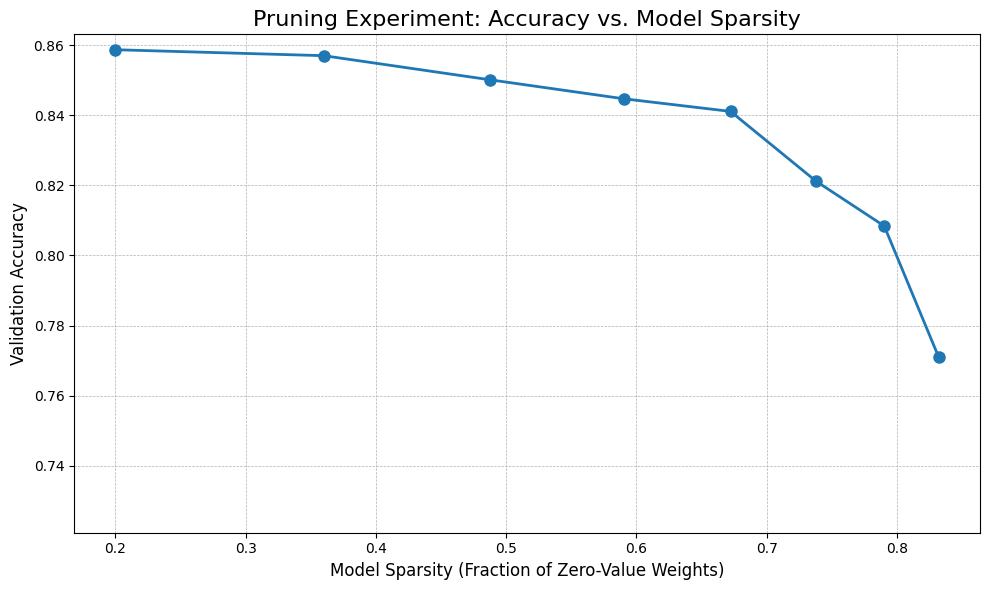

/tmp/ipykernel_792755/3581340762.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Precision', y='Accuracy', data=qat_results_df, palette=palette)


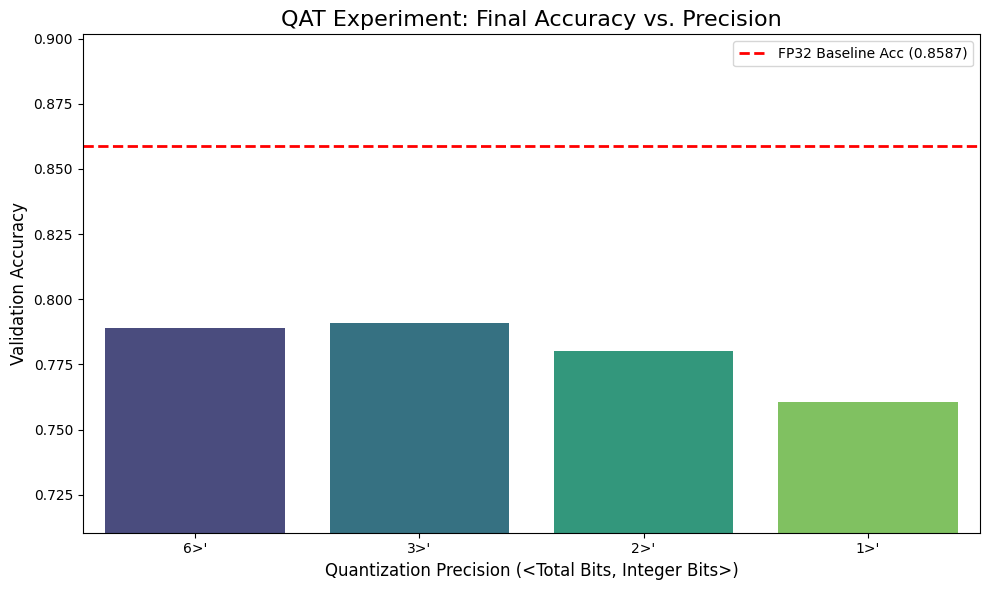

In [ ]:
# --- Plot 1: Pruning Results (Accuracy vs. Sparsity) ---
if 'pruning_results_df' in locals() and not pruning_results_df.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(pruning_results_df['Sparsity'], pruning_results_df['Accuracy'], 
             marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=8)
    plt.title('Pruning Experiment: Accuracy vs. Model Sparsity', fontsize=16)
    plt.xlabel('Model Sparsity (Fraction of Zero-Value Weights)', fontsize=12)
    plt.ylabel('Validation Accuracy', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.ylim(bottom=max(0, pruning_results_df['Accuracy'].min() - 0.05))
    plt.tight_layout()
    plt.show()
else:
    print("Pruning experiment did not produce results to analyze.")

# --- Plot 2: QAT Results (Accuracy per Precision) ---
if 'qat_results_df' in locals() and not qat_results_df.empty:
    plt.figure(figsize=(10, 6))
    
    # Get the baseline accuracy from the first pruning iteration (0% sparsity) if available
    baseline_acc = pruning_results_df['Accuracy'].iloc[0] if not pruning_results_df.empty else None

    # Create the bar plot
    palette = sns.color_palette("viridis", n_colors=len(qat_results_df))
    sns.barplot(x='Precision', y='Accuracy', data=qat_results_df, palette=palette)
    
    if baseline_acc:
        plt.axhline(y=baseline_acc, color='r', linestyle='--', linewidth=2, label=f'FP32 Baseline Acc ({baseline_acc:.4f})')
        plt.legend()

    plt.title('QAT Experiment: Final Accuracy vs. Precision', fontsize=16)
    plt.xlabel('Quantization Precision (<Total Bits, Integer Bits>)', fontsize=12)
    plt.ylabel('Validation Accuracy', fontsize=12)
    plt.ylim(bottom=max(0, qat_results_df['Accuracy'].min() - 0.05))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("QAT experiment did not produce results to analyze.")